# 10 — Early Danger Forecasting (v3)

**Frame2Threat v3** | Tests whether possession danger can be recognised *before* the possession completes.

This notebook implements four experiments:

- **EXP-015** — Start-only XGBoost
- **EXP-016** — Prefix GRU evaluation
- **EXP-017** — Cumulative-features XGBoost
- **EXP-019** — Tipping-point analysis

## 0. Imports & setup

In [ ]:
import os, sys, json, warnings
from pathlib import Path

_cwd = Path('.').resolve()
PROJECT_ROOT = _cwd if (_cwd / 'src').exists() else _cwd.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch

from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from xgboost import XGBClassifier

from src.data.parse_possessions import load_possession_sequences
from src.labels.possession_labels import attach_possession_labels
from src.features.possession_features import build_tabular_features
from src.features.early_features import (
    build_start_features,
    build_cumulative_tabular_features,
    START_ONLY_COLS,
    COMPLETION_DEPENDENT_COLS,
)
from src.evaluation.possession_attribution import load_gru_model
from src.evaluation.early_evaluation import (
    prefix_gru_auc_curve,
    tipping_point_analysis,
    tipping_summary_by_origin,
    tipping_event_type_distribution,
    max_delta_event_type_distribution,
)

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
LABEL = 'poss_dangerous'
FIG_DIR = Path('reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

with open('configs/model_possession.yaml') as f:
    poss_cfg = yaml.safe_load(f)

print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\USER\Documents\Python Projects\Frame2Threat


## 1. Load data & reproducible splits

In [2]:
poss = load_possession_sequences('data/processed/possession_sequences.parquet')
if 'poss_tempo' not in poss.columns:
    poss = attach_possession_labels(poss)

train_ids = pd.read_parquet('data/processed/train.parquet')['match_id'].unique()
val_ids   = pd.read_parquet('data/processed/val.parquet')['match_id'].unique()
test_ids  = pd.read_parquet('data/processed/test.parquet')['match_id'].unique()

train_poss = poss[poss['match_id'].isin(train_ids)].reset_index(drop=True)
val_poss   = poss[poss['match_id'].isin(val_ids)].reset_index(drop=True)
test_poss  = poss[poss['match_id'].isin(test_ids)].reset_index(drop=True)

print(f'Train: {len(train_poss):,} | Val: {len(val_poss):,} | Test: {len(test_poss):,}')
print(f'Danger rate (train/val/test): {train_poss[LABEL].mean():.3f} / {val_poss[LABEL].mean():.3f} / {test_poss[LABEL].mean():.3f}')

Train: 12,092 | Val: 2,498 | Test: 2,475
Danger rate (train/val/test): 0.320 / 0.330 / 0.360


In [ ]:
_xgb_early = poss_cfg['xgboost_early']

def fit_eval_xgb(X_tr, y_tr, X_va, y_va, X_te, y_te, *, random_state=_xgb_early['random_state']):
    model = XGBClassifier(
        n_estimators=_xgb_early['n_estimators'],
        max_depth=_xgb_early['max_depth'],
        learning_rate=_xgb_early['learning_rate'],
        subsample=_xgb_early['subsample'],
        colsample_bytree=_xgb_early['colsample_bytree'],
        min_child_weight=_xgb_early['min_child_weight'],
        reg_lambda=_xgb_early['reg_lambda'],
        objective='binary:logistic',
        eval_metric=_xgb_early['eval_metric'],
        random_state=random_state,
        n_jobs=_xgb_early['n_jobs'],
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    proba = model.predict_proba(X_te)[:, 1]
    return model, {
        'roc_auc': roc_auc_score(y_te, proba),
        'pr_auc': average_precision_score(y_te, proba),
        'proba': proba,
    }

results_registry = []

def log_result(experiment, model_name, fraction, roc_auc, pr_auc, n_features=None, notes=''):
    results_registry.append({
        'experiment': experiment,
        'model': model_name,
        'fraction': fraction,
        'roc_auc': round(float(roc_auc), 4),
        'pr_auc': round(float(pr_auc), 4),
        'n_features': n_features,
        'notes': notes,
    })

## 2. EXP-015 — Start-only XGBoost

Can danger be forecast from the *initial context* of a possession alone?

In [4]:
X_tr_start = build_start_features(train_poss).fillna(0)
X_va_start = build_start_features(val_poss).fillna(0)
X_te_start = build_start_features(test_poss).fillna(0)

y_tr = train_poss[LABEL].astype(int).values
y_va = val_poss[LABEL].astype(int).values
y_te = test_poss[LABEL].astype(int).values

xgb_start, res_start = fit_eval_xgb(
    X_tr_start, y_tr,
    X_va_start, y_va,
    X_te_start, y_te,
)

log_result('EXP-015', 'XGBoost start-only', '0%', res_start['roc_auc'], res_start['pr_auc'], len(X_tr_start.columns), 'Only possession-start features')

print('EXP-015 — Start-only XGBoost')
print(f"Features used: {len(X_tr_start.columns)}")
print(f"Test ROC-AUC: {res_start['roc_auc']:.4f}")
print(f"Test PR-AUC : {res_start['pr_auc']:.4f}")
pd.Series(xgb_start.feature_importances_, index=X_tr_start.columns).sort_values(ascending=False).head(10)

EXP-015 — Start-only XGBoost
Features used: 19
Test ROC-AUC: 0.6241
Test PR-AUC : 0.5346


origin_from_throw_in     0.168775
origin_from_free_kick    0.120735
start_x                  0.110839
start_x_norm             0.106964
origin_regular_play      0.066107
origin_from_corner       0.061554
origin_from_keeper       0.043334
dist_to_box_start        0.039429
origin_from_kick_off     0.038236
start_y_norm             0.036855
dtype: float32

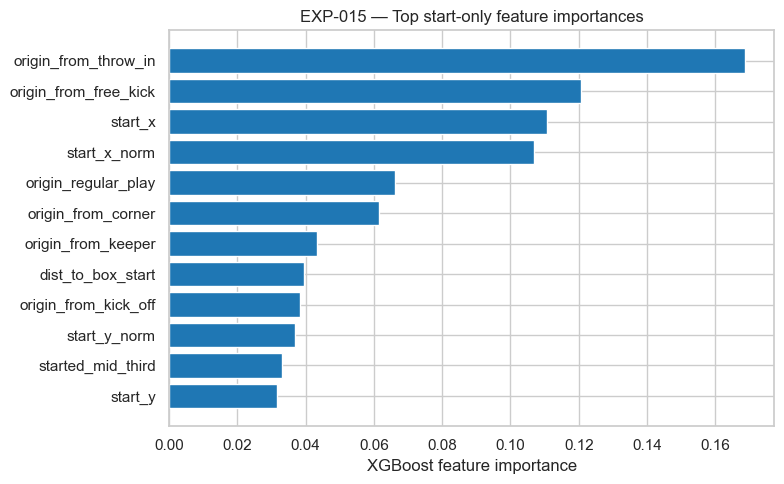

Saved → reports/figures/v3_exp015_start_only_importance.png


In [5]:
fi_start = pd.Series(xgb_start.feature_importances_, index=X_tr_start.columns).sort_values(ascending=True)
top_start = fi_start.tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_start.index, top_start.values, color='#1f77b4')
ax.set_title('EXP-015 — Top start-only feature importances')
ax.set_xlabel('XGBoost feature importance')
plt.tight_layout()
plt.savefig(FIG_DIR / 'v3_exp015_start_only_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/figures/v3_exp015_start_only_importance.png')

## 3. EXP-016 — Prefix GRU evaluation

How quickly does the sequence model recognise danger as events unfold?

In [6]:
gru_model, gru_cfg = load_gru_model('models/gru_poss_dangerous.pt')
print('Loaded GRU config:', gru_cfg)

gru_curve = prefix_gru_auc_curve(
    test_poss,
    gru_model,
    label_col=LABEL,
    fracs=(0.25, 0.50, 0.75, 1.00),
    min_events=4,
    verbose=True,
)

for _, row in gru_curve.iterrows():
    log_result('EXP-016', 'GRU prefix', row['pct_label'], row['roc_auc'], row['pr_auc'], 8, 'Existing v2 GRU scored on prefixes')

gru_curve

Loaded GRU config: {'input_size': 8, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'bidirectional': False, 'tab_size': 0, 'tab_features': []}
  Evaluating 2,249 possessions (≥4 events) …
    frac=25%  ROC-AUC=0.7167  PR-AUC=0.6761
    frac=50%  ROC-AUC=0.8195  PR-AUC=0.7732
    frac=75%  ROC-AUC=0.8793  PR-AUC=0.8468
    frac=100%  ROC-AUC=0.9475  PR-AUC=0.9283


,frac,pct_label,n_poss,roc_auc,pr_auc
0,0.25,25%,2249,0.7167,0.6761
1,0.50,50%,2249,0.8195,0.7732
2,0.75,75%,2249,0.8793,0.8468
3,1.00,100%,2249,0.9475,0.9283


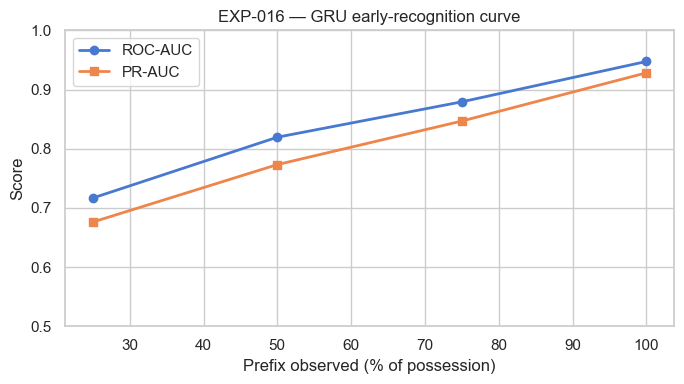

Saved → reports/figures/v3_exp016_prefix_gru_curve.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gru_curve['frac'] * 100, gru_curve['roc_auc'], marker='o', linewidth=2, label='ROC-AUC')
ax.plot(gru_curve['frac'] * 100, gru_curve['pr_auc'], marker='s', linewidth=2, label='PR-AUC')
ax.set_xlabel('Prefix observed (% of possession)')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.set_title('EXP-016 — GRU early-recognition curve')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'v3_exp016_prefix_gru_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/figures/v3_exp016_prefix_gru_curve.png')

## 4. EXP-017 — Cumulative-features XGBoost

If we rebuild tabular features from only the early part of the possession, how much performance remains?

In [8]:
cum_rows = []
cum_models = {}
for frac in (0.25, 0.50, 0.75, 1.00):
    X_tr_c = build_cumulative_tabular_features(train_poss, frac=frac).fillna(0)
    X_va_c = build_cumulative_tabular_features(val_poss, frac=frac).fillna(0)
    X_te_c = build_cumulative_tabular_features(test_poss, frac=frac).fillna(0)

    model_c, res_c = fit_eval_xgb(X_tr_c, y_tr, X_va_c, y_va, X_te_c, y_te)
    cum_models[frac] = model_c
    row = {
        'frac': frac,
        'pct_label': f'{frac:.0%}',
        'n_features': X_tr_c.shape[1],
        'roc_auc': res_c['roc_auc'],
        'pr_auc': res_c['pr_auc'],
    }
    cum_rows.append(row)
    log_result('EXP-017', 'XGBoost cumulative', row['pct_label'], row['roc_auc'], row['pr_auc'], row['n_features'], 'Features rebuilt from prefix only')
    print(f"frac={frac:.0%} | ROC-AUC={row['roc_auc']:.4f} | PR-AUC={row['pr_auc']:.4f}")

cum_curve = pd.DataFrame(cum_rows)
cum_curve

frac=25% | ROC-AUC=0.8136 | PR-AUC=0.7127
frac=50% | ROC-AUC=0.8472 | PR-AUC=0.7624
frac=75% | ROC-AUC=0.8912 | PR-AUC=0.8200
frac=100% | ROC-AUC=0.9517 | PR-AUC=0.8978


,frac,pct_label,n_features,roc_auc,pr_auc
0,0.25,25%,41,0.813579,0.712682
1,0.50,50%,41,0.847167,0.762407
2,0.75,75%,41,0.891240,0.820013
3,1.00,100%,41,0.951678,0.897800


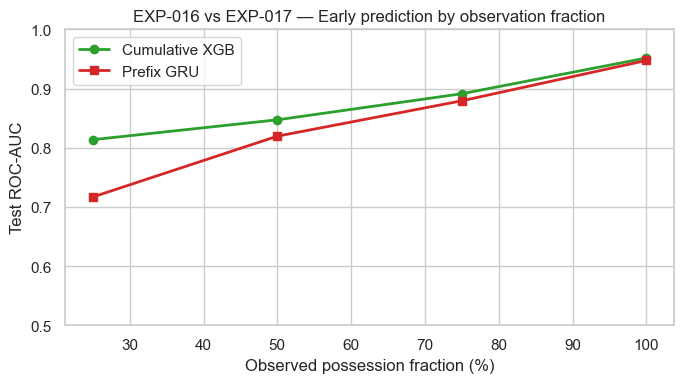

Saved → reports/figures/v3_exp016_exp017_auc_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cum_curve['frac'] * 100, cum_curve['roc_auc'], marker='o', linewidth=2, color='#2ca02c', label='Cumulative XGB')
ax.plot(gru_curve['frac'] * 100, gru_curve['roc_auc'], marker='s', linewidth=2, color='#d62728', label='Prefix GRU')
ax.set_xlabel('Observed possession fraction (%)')
ax.set_ylabel('Test ROC-AUC')
ax.set_ylim(0.5, 1.0)
ax.set_title('EXP-016 vs EXP-017 — Early prediction by observation fraction')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'v3_exp016_exp017_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/figures/v3_exp016_exp017_auc_comparison.png')

## 5. EXP-019 — Tipping-point analysis

Which events most often trigger the model's jump into the dangerous regime?

In [ ]:
tip_df = tipping_point_analysis(
    test_poss,
    gru_model,
    label_col=LABEL,
    threshold=0.50,
    min_events=3,
    verbose=True,
)

tip_origin = tipping_summary_by_origin(tip_df, test_poss)
tip_event_dist = tipping_event_type_distribution(tip_df)
max_delta_dist = max_delta_event_type_distribution(tip_df)

cross_rate = (tip_df['tipping_step'] >= 0).mean()
danger_cross_rate = (tip_df.loc[tip_df['poss_dangerous'] == 1, 'tipping_step'] >= 0).mean()
median_tip_frac = tip_df.loc[tip_df['tipping_step'] >= 0, 'tipping_frac'].median()

log_result('EXP-019', 'GRU tipping-point', 'threshold=0.50', 0.0, 0.0, None,
           f'Cross-rate={cross_rate:.3f}; dangerous-only={danger_cross_rate:.3f}; median tipping frac={median_tip_frac:.3f}')

print(f'All possessions crossing 0.50: {cross_rate:.3%}')
print(f'Dangerous possessions crossing 0.50: {danger_cross_rate:.3%}')
print(f'Median tipping fraction among crossings: {median_tip_frac:.3f}')
tip_event_dist.head(10)

  Tipping-point analysis: 2000/2475
All possessions crossing 0.50: 47.539%
Dangerous possessions crossing 0.50: 91.972%
Median tipping fraction among crossings: 0.619


,event_type,count,pct
0,Dribble,728,64.4
1,Shot,116,10.3
2,Carry,111,9.8
3,Other,62,5.5
4,Duel,52,4.6
5,Ball Receipt,21,1.9
6,Pressure,13,1.2
7,Clearance,12,1.1
8,Pass,8,0.7
9,Interception,7,0.6


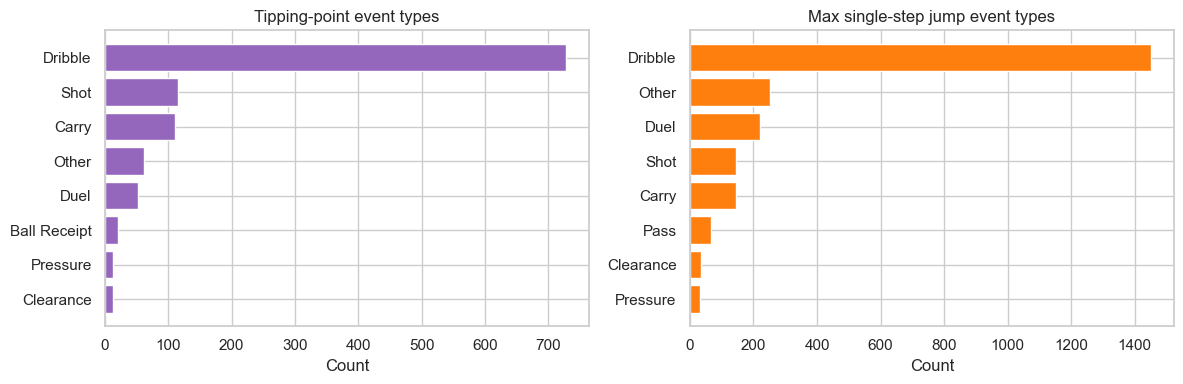

Saved → reports/figures/v3_exp019_tipping_events.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot1 = tip_event_dist.head(8).sort_values('count')
axes[0].barh(plot1['event_type'], plot1['count'], color='#9467bd')
axes[0].set_title('Tipping-point event types')
axes[0].set_xlabel('Count')

plot2 = max_delta_dist.head(8).sort_values('count')
axes[1].barh(plot2['event_type'], plot2['count'], color='#ff7f0e')
axes[1].set_title('Max single-step jump event types')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(FIG_DIR / 'v3_exp019_tipping_events.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/figures/v3_exp019_tipping_events.png')

In [15]:
tip_origin.head(10)

,n,n_tipped,median_tipping_frac,mean_final_score,pct_tipped
origin_type,,,,,
From Corner,123,119,0.091,0.868401,96.7
From Throw In,525,269,0.600,0.744353,51.2
From Free Kick,362,184,0.556,0.802958,50.8
Other,6,3,0.000,0.854957,50.0
From Counter,52,24,0.727,0.818121,46.2
Regular Play,951,398,0.700,0.804595,41.9
From Goal Kick,217,89,0.706,0.790192,41.0
From Kick Off,65,22,0.812,0.699737,33.8
From Keeper,76,22,0.750,0.769858,28.9


## 6. Consolidated results

In [18]:
results_df = pd.DataFrame(results_registry)

results_df = results_df.drop_duplicates(subset=['experiment', 'model', 'fraction'], keep='last').reset_index(drop=True)

results_df


,experiment,model,fraction,roc_auc,pr_auc,n_features,notes
0,EXP-015,XGBoost start-only,0%,0.6241,0.5346,19.0,Only possession-start features
1,EXP-016,GRU prefix,25%,0.7167,0.6761,8.0,Existing v2 GRU scored on prefixes
2,EXP-016,GRU prefix,50%,0.8195,0.7732,8.0,Existing v2 GRU scored on prefixes
3,EXP-016,GRU prefix,75%,0.8793,0.8468,8.0,Existing v2 GRU scored on prefixes
4,EXP-016,GRU prefix,100%,0.9475,0.9283,8.0,Existing v2 GRU scored on prefixes
5,EXP-017,XGBoost cumulative,25%,0.8136,0.7127,41.0,Features rebuilt from prefix only
6,EXP-017,XGBoost cumulative,50%,0.8472,0.7624,41.0,Features rebuilt from prefix only
7,EXP-017,XGBoost cumulative,75%,0.8912,0.8200,41.0,Features rebuilt from prefix only
8,EXP-017,XGBoost cumulative,100%,0.9517,0.8978,41.0,Features rebuilt from prefix only
9,EXP-019,GRU tipping-point,threshold=0.50,0.0000,0.0000,NaN,Cross-rate=0.475; dangerous-only=0.920; median...


In [17]:
full_tab_auc = float(cum_curve.loc[cum_curve['frac'] == 1.0, 'roc_auc'].iloc[0])
full_gru_auc = float(gru_curve.loc[gru_curve['frac'] == 1.0, 'roc_auc'].iloc[0])
start_auc = float(res_start['roc_auc'])
half_gru_auc = float(gru_curve.loc[gru_curve['frac'] == 0.5, 'roc_auc'].iloc[0])
half_xgb_auc = float(cum_curve.loc[cum_curve['frac'] == 0.5, 'roc_auc'].iloc[0])

summary = pd.DataFrame([
    {'claim': 'Start-only context already carries predictive signal', 'value': start_auc},
    {'claim': 'GRU at 50% of possession', 'value': half_gru_auc},
    {'claim': 'Cumulative XGB at 50% of possession', 'value': half_xgb_auc},
    {'claim': 'Full cumulative XGB', 'value': full_tab_auc},
    {'claim': 'Full GRU', 'value': full_gru_auc},
])
summary

,claim,value
0,Start-only context already carries predictive ...,0.624089
1,GRU at 50% of possession,0.819500
2,Cumulative XGB at 50% of possession,0.847167
3,Full cumulative XGB,0.951678
4,Full GRU,0.947500
